In [2]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


C:\Users\NOUR\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
plt.style.use('ggplot')
color_pal = plt.rcParams["axes.prop_cycle"].by_key()['color']

In [4]:
data_folder_path = 'E:/NOUR/Documents/PFE/data/'
files = os.listdir(data_folder_path)

all_months_data = pd.DataFrame()

for file in files:
    if file.endswith('_2019.csv'):
        file_path = os.path.join(data_folder_path, file)
        data_set = pd.read_csv(file_path)
        
        all_months_data = pd.concat([all_months_data, data_set], ignore_index=True)

all_months_data.to_csv('all_data.csv', index=False)

In [5]:
all_data = pd.read_csv('all_data.csv')
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101"
1,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001"
2,236672,iPhone,1,700.0,08/06/19 14:40,"149 7th St, Portland, OR 97035"
3,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001"
4,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001"


In [6]:
all_data.dtypes


Order ID            object
Product             object
Quantity Ordered    object
Price Each          object
Order Date          object
Purchase Address    object
dtype: object

In [7]:
all_data.isna().any()


Order ID            True
Product             True
Quantity Ordered    True
Price Each          True
Order Date          True
Purchase Address    True
dtype: bool

In [8]:
all_data = all_data.dropna()

In [9]:

all_data = all_data[all_data['Order Date'].str[0:2] != 'Or']
all_data['Order Date'] = pd.to_datetime(all_data['Order Date'], format='%m/%d/%y %H:%M')
all_data['Month'] = all_data['Order Date'].dt.month

In [10]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,236670,Wired Headphones,2,11.99,2019-08-31 22:21:00,"359 Spruce St, Seattle, WA 98101",8
1,236671,Bose SoundSport Headphones,1,99.99,2019-08-15 15:11:00,"492 Ridge St, Dallas, TX 75001",8
2,236672,iPhone,1,700.0,2019-08-06 14:40:00,"149 7th St, Portland, OR 97035",8
3,236673,AA Batteries (4-pack),2,3.84,2019-08-29 20:59:00,"631 2nd St, Los Angeles, CA 90001",8
4,236674,AA Batteries (4-pack),2,3.84,2019-08-15 19:53:00,"736 14th St, New York City, NY 10001",8


In [11]:
def get_city(address):
    return address.split(',')[1]

def get_state(address):
    return address.split(',')[2].split(' ')[1]

all_data['City'] = all_data['Purchase Address'].apply(lambda x: f"{get_city(x)} ({get_state(x)})")
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,City
0,236670,Wired Headphones,2,11.99,2019-08-31 22:21:00,"359 Spruce St, Seattle, WA 98101",8,Seattle (WA)
1,236671,Bose SoundSport Headphones,1,99.99,2019-08-15 15:11:00,"492 Ridge St, Dallas, TX 75001",8,Dallas (TX)
2,236672,iPhone,1,700.0,2019-08-06 14:40:00,"149 7th St, Portland, OR 97035",8,Portland (OR)
3,236673,AA Batteries (4-pack),2,3.84,2019-08-29 20:59:00,"631 2nd St, Los Angeles, CA 90001",8,Los Angeles (CA)
4,236674,AA Batteries (4-pack),2,3.84,2019-08-15 19:53:00,"736 14th St, New York City, NY 10001",8,New York City (NY)


In [12]:
all_data.dtypes

Order ID                    object
Product                     object
Quantity Ordered            object
Price Each                  object
Order Date          datetime64[ns]
Purchase Address            object
Month                        int32
City                        object
dtype: object

In [13]:
all_data['Quantity Ordered'] = pd.to_numeric(all_data['Quantity Ordered'], errors='coerce')
all_data['Price Each'] = pd.to_numeric(all_data['Price Each'], errors='coerce')

In [14]:
all_data['Sales'] = all_data['Quantity Ordered'] * all_data['Price Each']

In [15]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,City,Sales
0,236670,Wired Headphones,2,11.99,2019-08-31 22:21:00,"359 Spruce St, Seattle, WA 98101",8,Seattle (WA),23.98
1,236671,Bose SoundSport Headphones,1,99.99,2019-08-15 15:11:00,"492 Ridge St, Dallas, TX 75001",8,Dallas (TX),99.99
2,236672,iPhone,1,700.00,2019-08-06 14:40:00,"149 7th St, Portland, OR 97035",8,Portland (OR),700.00
3,236673,AA Batteries (4-pack),2,3.84,2019-08-29 20:59:00,"631 2nd St, Los Angeles, CA 90001",8,Los Angeles (CA),7.68
4,236674,AA Batteries (4-pack),2,3.84,2019-08-15 19:53:00,"736 14th St, New York City, NY 10001",8,New York City (NY),7.68


In [16]:
#the best month for sales and How much was earned that month

In [17]:
months = [1,2,3,8,9,10]
sales_by_month = all_data.groupby('Month')['Sales'].sum()
sales_by_month

Month
1     1813586.44
2     2202022.42
3        3207.50
8     2242315.57
9     2097560.13
10       3353.31
Name: Sales, dtype: float64

In [18]:
len(sales_by_month)

6

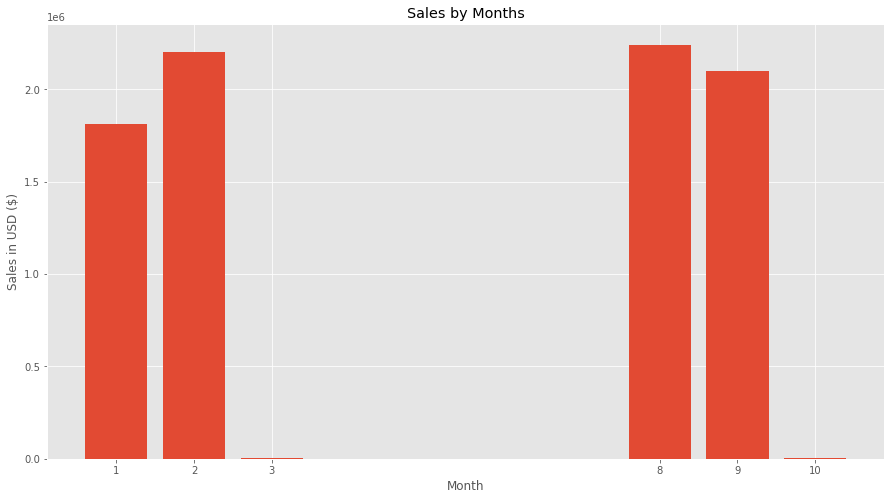

In [19]:
plt.figure(figsize=(15, 8))
plt.bar(months, sales_by_month)
plt.xlabel('Month')
plt.ylabel('Sales in USD ($)')
plt.title('Sales by Months')
plt.xticks(months)
plt.show()

In [20]:
# What city had the highest number of sales

In [21]:
cities = [city for city, df in all_data.groupby('City')]
sales_by_city = all_data.groupby('City')['Sales'].sum()

In [22]:
sales_by_city

City
 Atlanta (GA)           666276.38
 Austin (TX)            428701.67
 Boston (MA)            903216.92
 Dallas (TX)            672394.86
 Los Angeles (CA)      1329455.63
 New York City (NY)    1169095.45
 Portland (ME)          116710.45
 Portland (OR)          433206.13
 San Francisco (CA)    1985031.21
 Seattle (WA)           657956.67
Name: Sales, dtype: float64

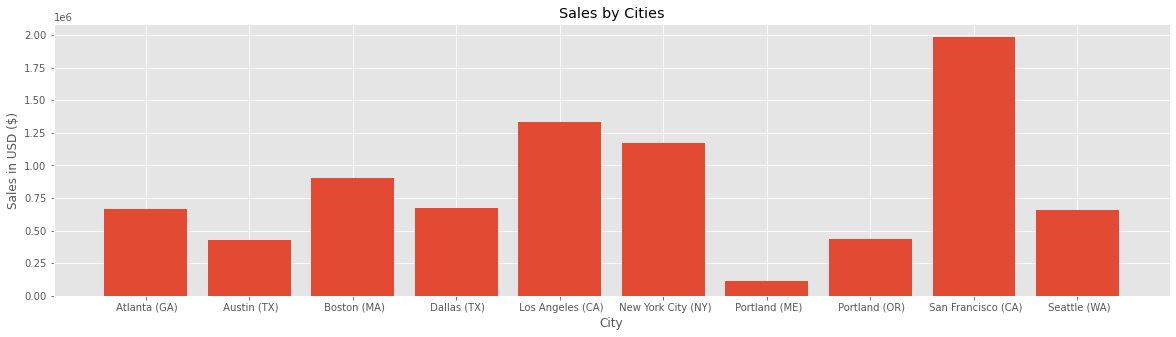

In [23]:
plt.figure(figsize=(20, 5))
plt.bar(cities, sales_by_city)
plt.xlabel('City')
plt.ylabel('Sales in USD ($)')
plt.title('Sales by Cities')
plt.show()

In [24]:
#What time should we display advertisements to maximize likelihood of customers buying products

In [25]:
all_data['Hour'] = all_data['Order Date'].dt.hour
all_data['Minute'] = all_data['Order Date'].dt.minute

In [26]:
hours = [hour for hour, df in all_data.groupby('Hour')]

In [27]:
print(all_data['Hour'].unique())


[22 15 14 20 19 23  7 12 16 10 13 21  0  8 11  6  9  2 17 18  1  5  3  4]


Text(0.5, 0, 'Hours')

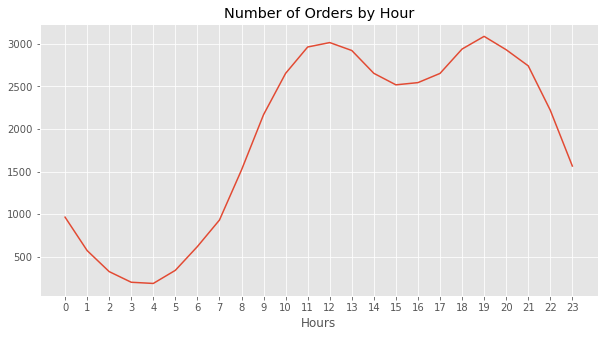

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(hours, all_data.groupby(['Hour'])['Order ID'].count().values)  # Select the 'Order ID' column and use .values
plt.xticks(hours)
plt.title("Number of Orders by Hour")
plt.xlabel('Hours')


In [29]:
#What products are most often sold together

In [30]:
df = all_data[all_data['Order ID'].duplicated(keep = False)]
df['Grouped'] = df.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))
df = df[['Order ID', 'Grouped']].drop_duplicates()
df

,Order ID,Grouped
46,236716,"AA Batteries (4-pack),USB-C Charging Cable"
60,236729,"iPhone,Apple Airpods Headphones"
62,236730,"Google Phone,Wired Headphones"
132,236799,"Google Phone,Wired Headphones"
163,236829,"Vareebadd Phone,USB-C Charging Cable"
...,...,...
45387,259296,"Apple Airpods Headphones,Apple Airpods Headphones"
45389,259297,"iPhone,Lightning Charging Cable,Lightning Char..."
45397,259303,"34in Ultrawide Monitor,AA Batteries (4-pack)"
45409,259314,"Wired Headphones,AAA Batteries (4-pack)"


In [31]:
from itertools import combinations
from collections import Counter

count = Counter()

for row in df['Grouped']:
    row_list = row.split(',')
    count.update(Counter(combinations(row_list, 2)))
    
for key,value in count.most_common(10):
    print(key, value)

('Google Phone', 'USB-C Charging Cable') 259
('iPhone', 'Lightning Charging Cable') 237
('iPhone', 'Wired Headphones') 116
('Google Phone', 'Wired Headphones') 99
('Vareebadd Phone', 'USB-C Charging Cable') 86
('iPhone', 'Apple Airpods Headphones') 83
('Google Phone', 'Bose SoundSport Headphones') 48
('USB-C Charging Cable', 'Wired Headphones') 42
('Vareebadd Phone', 'Wired Headphones') 35
('Lightning Charging Cable', 'Wired Headphones') 24


In [32]:
#What product sold the most

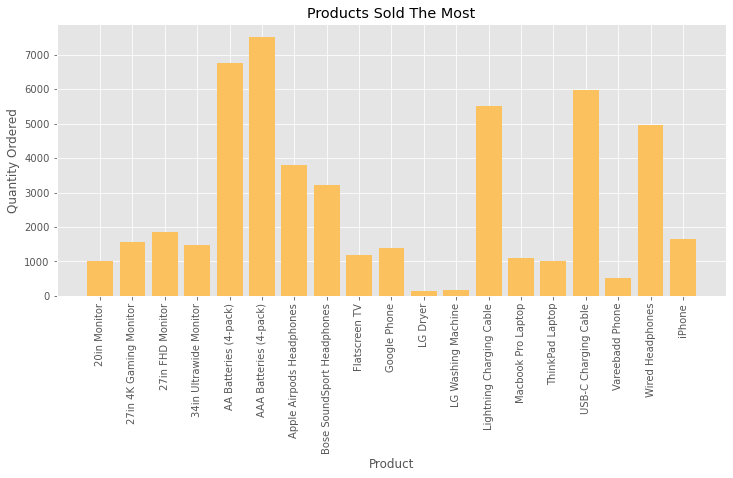

In [33]:
product_group = all_data.groupby('Product')
quantity_ordered = product_group['Quantity Ordered'].sum()

products = [product for product, df in product_group]

plt.figure(figsize=(12,5))
plt.bar(products, quantity_ordered, color= color_pal[4])
plt.title('Products Sold The Most')
plt.ylabel('Quantity Ordered')
plt.xlabel('Product')
plt.xticks(products, rotation='vertical')
plt.show()

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Convert lists to NumPy arrays
products_array = np.array(products)
quantity_ordered_array = np.array(quantity_ordered)
prices_array = np.array(prices)

# Create a figure and axis
fig, ax1 = plt.subplots(figsize=(20, 5))

# Create the bar chart for quantity_ordered
ax1.bar(products_array, quantity_ordered_array, color='b', alpha=0.7, label='Quantity Ordered')
ax1.set_xlabel('Product Name')
ax1.set_ylabel('Quantity Ordered', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Create a secondary y-axis
ax2 = ax1.twinx()

# Create the line chart for prices on the secondary y-axis
ax2.plot(products_array, prices_array, color='g', marker='o', label='Prices')
ax2.set_ylabel('Prices', color='g')
ax2.tick_params(axis='y', labelcolor='g')

# Adding legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title("Quantity Ordered and Prices by Product")
plt.xticks(rotation='vertical')

plt.tight_layout()
plt.show()


NameError: name 'prices' is not defined

In [42]:
import pymongo
from pymongo import MongoClient
con = pymongo.MongoClient("mongodb://localhost:27017/")
db = con.DCSTEC
collection = db.Sales

In [43]:
data = all_data.to_dict(orient='records')
collection.insert_many(data)

In [41]:
collection.delete_many({})